# SIT307 11.1HD — Part 1: Reproduction of Bhagat et al. (2025)

**Paper:** M. Bhagat, A. Sharma, P. Agarwal, "An efficient stacking-based ensemble technique for early heart attack prediction," *Multimedia Tools and Applications*, vol. 84, pp. 36351–36375, 2025, doi: 10.1007/s11042-024-19293-7.

**Goal of this notebook:** reproduce the paper's pipeline as faithfully as possible (same dataset, feature set, split strategy, preprocessing, six base classifiers, 5-fold stacking, and metrics), compare the reproduced results with Table 11 of the paper, and analyse discrepancies.

Structure:
1. Dataset and data-quality audit (on the raw file, before any preprocessing)
2. Preprocessing (as described in Section 3.1) and stated assumptions
3. Train/test split (80/20, inferred from the paper's confusion matrices)
4. Six base classifiers + stacking, single split (seed 42)
5. Comparison with the paper (Table 11)
6. Robustness of the reproduction across 20 random splits, all metrics beside the paper (6.1), and a hyperparameter analysis of the tree-based models (6.2)
7. Consistency check of the paper's own reported numbers, cross-check with the original UCI data (7.1), and sensitivity to the handling of `ca = 4` and `thal = 0` (7.2)
8. Diagnostic: train/test overlap caused by duplicate rows
9. Summary

All fitted steps (imputation, encoding, scaling, classifiers) are wrapped in sklearn `Pipeline`s defined in `src/heart_utils.py`, so they are fitted on the training split only.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

# Locate project root (folder that contains src/), whether run from root or notebooks/
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from heart_utils import (load_data, FEATURES, TARGET, INVALID_CODES, MODEL_ORDER,
                         make_all_pipelines, fit_and_score, metrics_from_confusion,
                         overlap_rate, row_keys)

DATA_PATH = ROOT / "data" / "heart.csv"
FIG_DIR = ROOT / "figures"; FIG_DIR.mkdir(exist_ok=True)
RES_DIR = ROOT / "results"; RES_DIR.mkdir(exist_ok=True)

SEED = 42          # main reproduction split / model seed
N_SEEDS = 20       # number of random splits for the robustness analysis
pd.set_option("display.precision", 4)
print("Project root:", ROOT)

Project root: c:\Users\vngak\OneDrive\Documents\SIT307\sit307_11_1HD


## 1. Dataset and data-quality audit

Section 4 of the paper uses the Kaggle *Heart Disease Dataset* (https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset), 1025 records and 14 attributes (13 features + binary `target`). The Kaggle page and the paper describe `target = 1` as disease; the label is used as-is to reproduce the paper (see Section 7.1). The paper does not cite a separate reference for the dataset and states that data are only available on request, so this Kaggle file is the only identifiable source.

All checks below are computed on the **raw file**, before any cleaning or imputation.

In [2]:
df = load_data(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.describe().T[["min", "max", "mean"]])

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,min,max,mean
age,29.0,77.0,54.4341
sex,0.0,1.0,0.6956
cp,0.0,3.0,0.9424
trestbps,94.0,200.0,131.6117
chol,126.0,564.0,246.0000
fbs,0.0,1.0,0.1493
restecg,0.0,2.0,0.5298
thalach,71.0,202.0,149.1141
exang,0.0,1.0,0.3366
oldpeak,0.0,6.2,1.0715


In [3]:
audit = {}
audit["rows"] = len(df)
audit["NaN cells"] = int(df.isna().sum().sum())
for col, bad in INVALID_CODES.items():
    audit[f"rows with {col}={bad} (outside Table 9 range)"] = int((df[col] == bad).sum())
audit["exact duplicate rows"] = int(df.duplicated().sum())
audit["unique rows"] = int(len(df.drop_duplicates()))
copies = df.groupby(list(df.columns)).size().value_counts().sort_index()
audit["copies per unique row"] = copies.to_dict()
unique_feat = df.drop_duplicates()
audit["duplicated features with conflicting labels"] = int((unique_feat.groupby(FEATURES)[TARGET].nunique() > 1).sum())
audit["class counts (all rows)"] = df[TARGET].value_counts().sort_index().to_dict()
audit["class counts (unique rows)"] = unique_feat[TARGET].value_counts().sort_index().to_dict()
for k, v in audit.items():
    print(f"{k:50s}: {v}")

rows                                              : 1025
NaN cells                                         : 0
rows with ca=4 (outside Table 9 range)            : 18
rows with thal=0 (outside Table 9 range)          : 7
exact duplicate rows                              : 723
unique rows                                       : 302
copies per unique row                             : {3: 187, 4: 114, 8: 1}
duplicated features with conflicting labels       : 0
class counts (all rows)                           : {0: 499, 1: 526}
class counts (unique rows)                        : {0: 138, 1: 164}


**Observations (raw data):**
- There are no `NaN` cells, although the paper describes a missing-value imputation step. However, `ca = 4` and `thal = 0` fall outside the value ranges the paper itself gives in Table 9 (`ca` 0–3, `thal` 1–3). These codes correspond to entries marked `?` (missing) in the original UCI data, so they are treated as missing values here.
- A large share of the rows are exact duplicates; the number of unique records is printed above. This matters for any random train/test split and is analysed in Section 8. It is **not** corrected in Part 1, because the goal here is to reproduce the paper's protocol; it is the limitation addressed in Part 2.
- Classes are close to balanced, so no resampling is applied (the paper does not mention any).

## 2. Preprocessing and assumptions

The paper (Section 3.1, Table 8) describes: fill missing values with linear-regression imputation, normalise numeric attributes, encode categorical attributes, then split and train. Implementation details are not reported, so the following assumptions are made:

| Step | Paper | Implementation here (assumption + justification) |
|---|---|---|
| Missing values | "basic linear regression imputation ... using the correlation matrix" | Invalid codes (`ca=4`, `thal=0`) are marked missing and predicted from the other attributes with `IterativeImputer(LinearRegression)`; imputed codes are rounded and clipped to the valid range. |
| Normalisation | "converts numeric attributes to a similar scale without distorting ranges" | `MinMaxScaler` on `age, trestbps, chol, thalach, oldpeak, ca` (min–max scaling preserves relative ranges, matching the wording). |
| Encoding | "encoding the categories" | One-hot encoding for nominal codes `cp, restecg, slope, thal` (codes have no numeric meaning); binary `sex, fbs, exang` unchanged. |
| Fitting | Table 8: split first, then preprocess | All preprocessing is inside the pipeline and fitted on the training split only. |
| Hyperparameters | not reported | Library defaults; Decision Tree uses `criterion="entropy"` (Eq. 2, Table 3); KNN uses Euclidean distance (Table 7), K = 5 (default). |
| Stacking | "5-fold stacking", meta-classifier trained on base predictions | `StackingClassifier` with all six classifiers, `cv=5`, out-of-fold probabilities as meta-features; meta-classifier = Logistic Regression (not named in the paper). |

## 3. Train/test split

The paper does not state the split ratio or random seed. It can be **inferred from the paper's own confusion matrices** (Fig. 3 and Fig. 5): every matrix sums to 205 test samples, and 205 / 1025 = 20%. The paper's test set contains 95 negatives and 110 positives; a stratified 20% split would give about 100/105, so the split was most likely not stratified. A plain random 80/20 split (not stratified) is therefore used.

In [4]:
X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Test class counts:", y_test.value_counts().sort_index().to_dict(), "(paper: {0: 95, 1: 110})")

Train: (820, 13)  Test: (205, 13)
Test class counts: {0: 102, 1: 103} (paper: {0: 95, 1: 110})


## 4. Six base classifiers and stacking (single split, seed 42)

Models: Logistic Regression (LR), Decision Tree (DT), Random Forest (RF), XGBoost (XGB), Gaussian Naive Bayes (NB), K-Nearest Neighbours (KNN), and the stacking ensemble of all six. AUC is computed from predicted probabilities.

In [5]:
pipelines = make_all_pipelines(SEED)
fitted, rows, preds, scores = {}, {}, {}, {}
for name in MODEL_ORDER:
    model, res, y_pred, y_score = fit_and_score(pipelines[name], X_train, y_train, X_test, y_test)
    fitted[name], rows[name], preds[name], scores[name] = model, res, y_pred, y_score

repro = pd.DataFrame(rows).T[["Accuracy", "Precision", "Recall", "F1", "AUC", "Specificity", "MCC"]]
repro.to_csv(RES_DIR / "part1_single_split_seed42.csv")
display(repro)

,Accuracy,Precision,Recall,F1,AUC,Specificity,MCC
LR,0.8293,0.7833,0.9126,0.8430,0.9050,0.7451,0.6675
DT,0.9854,1.0000,0.9709,0.9852,0.9854,1.0000,0.9712
RF,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712
XGB,0.9854,1.0000,0.9709,0.9852,0.9806,1.0000,0.9712
NB,0.8244,0.7913,0.8835,0.8349,0.8557,0.7647,0.6531
KNN,0.8488,0.8273,0.8835,0.8545,0.9585,0.8137,0.6991
Stacking,0.9854,1.0000,0.9709,0.9852,1.0000,1.0000,0.9712


## 5. Comparison with the paper (Table 11)

Values below are copied from Table 11 of the paper. (Section 7 shows that some columns of Table 11 are internally inconsistent; the Accuracy, Precision, Recall, F1 and AUC columns are the ones used for comparison.)

In [6]:
paper = pd.DataFrame({
    "Accuracy":  [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    "Precision": [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0000],
    "Recall":    [0.9090, 0.8909, 0.9545, 0.9090, 0.9000, 0.8727, 0.9727],
    "F1":        [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    "AUC":       [0.9204, 0.9702, 0.9734, 0.9830, 0.9185, 0.9304, 0.9880],
}, index=MODEL_ORDER)
paper.to_csv(RES_DIR / "paper_table11.csv")

main_metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
comparison = pd.concat({"Paper": paper, "Reproduced (seed 42)": repro[main_metrics],
                        "Difference": repro[main_metrics] - paper}, axis=1)
display(comparison.round(4))

Paper                                   Reproduced (seed 42)  \
         Accuracy Precision  Recall      F1     AUC             Accuracy   
LR         0.8439    0.8196  0.9090  0.8620  0.9204               0.8293   
DT         0.9268    0.9702  0.8909  0.9289  0.9702               0.9854   
RF         0.9268    0.9130  0.9545  0.9333  0.9734               0.9854   
XGB        0.9073    0.9174  0.9090  0.9132  0.9830               0.9854   
NB         0.8439    0.8250  0.9000  0.8608  0.9185               0.8244   
KNN        0.8585    0.8648  0.8727  0.8687  0.9304               0.8488   
Stacking   0.9853    1.0000  0.9727  0.9861  0.9880               0.9854   

                                           Difference                    \
         Precision  Recall      F1     AUC   Accuracy Precision  Recall   
LR          0.7833  0.9126  0.8430  0.9050    -0.0146   -0.0363  0.0036   
DT          1.0000  0.9709  0.9852  0.9854     0.0586    0.0298  0.0800   
RF          1.0000  0.9709  0.9852  1.0000     0.0586    0.0870  0.0164   
XGB         1.0000  0.9709  0.9852  0.9806     0.0781    0.0826  0.0619   
NB          0.7913  0.8835  0.8349  0.8557    -0.0195   -0.0337 -0.0165   
KNN         0.8273  0.8835  0.8545  0.9585    -0.0097   -0.0375  0.0108   
Stacking    1.0000  0.9709  0.9852  1.0000     0.0001    0.0000 -0.0018   

                          
              F1     AUC  
LR       -0.0190 -0.0154  
DT        0.0563  0.0152  
RF        0.0519  0.0266  
XGB       0.0720 -0.0024  
NB       -0.0259 -0.0628  
KNN      -0.0142  0.0281  
Stacking -0.0009  0.0120

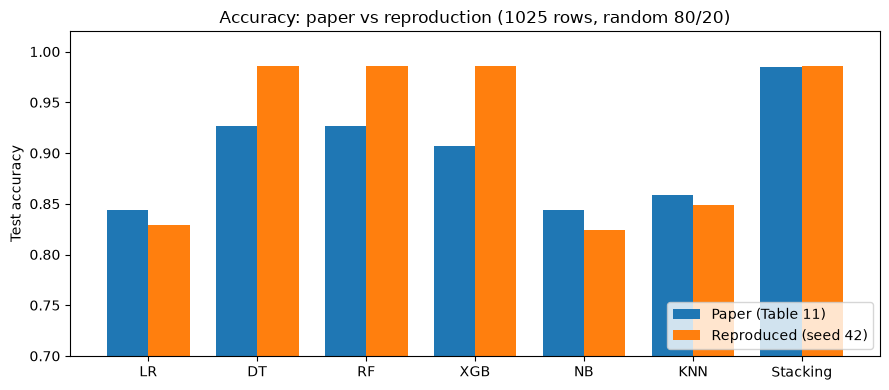

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(MODEL_ORDER)); w = 0.38
ax.bar(x - w/2, paper["Accuracy"], w, label="Paper (Table 11)")
ax.bar(x + w/2, repro["Accuracy"], w, label="Reproduced (seed 42)")
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER); ax.set_ylim(0.7, 1.02)
ax.set_ylabel("Test accuracy"); ax.set_title("Accuracy: paper vs reproduction (1025 rows, random 80/20)")
ax.legend(loc="lower right"); fig.tight_layout()
fig.savefig(FIG_DIR / "p1_accuracy_paper_vs_repro.png", dpi=200); plt.show()

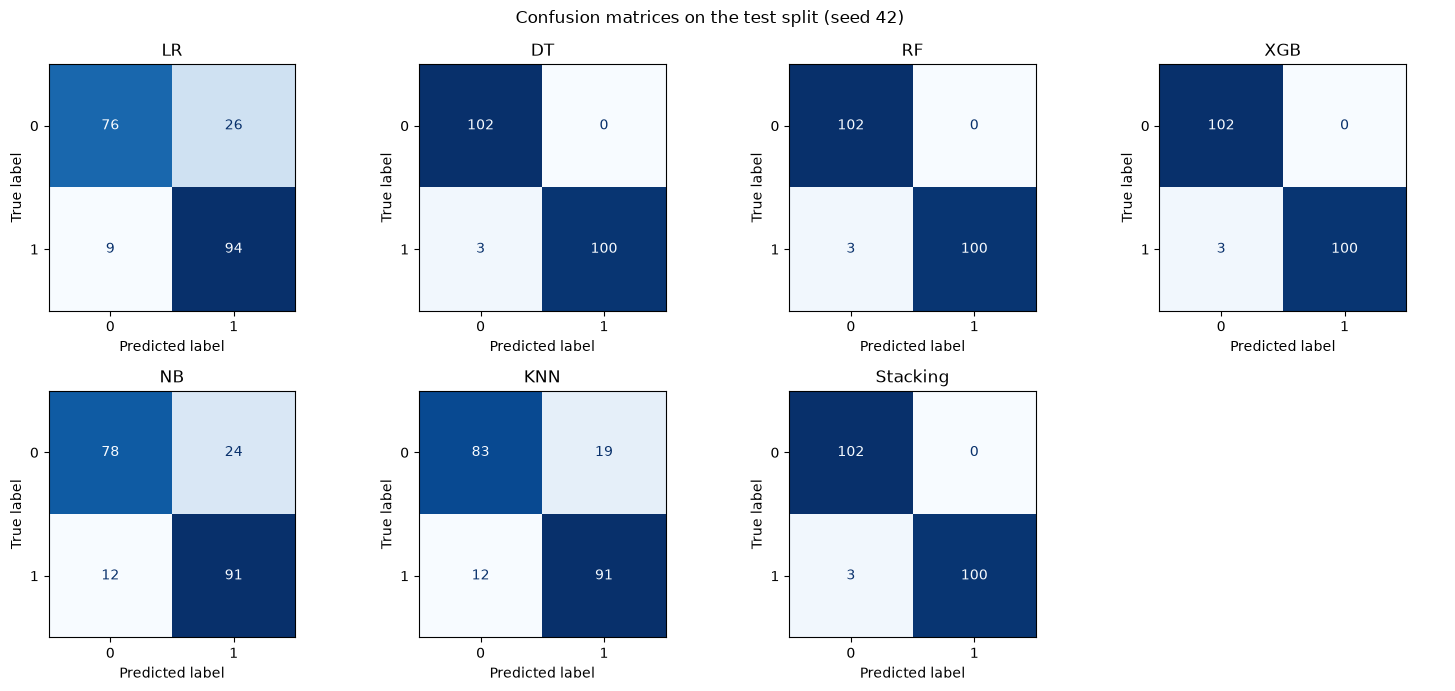

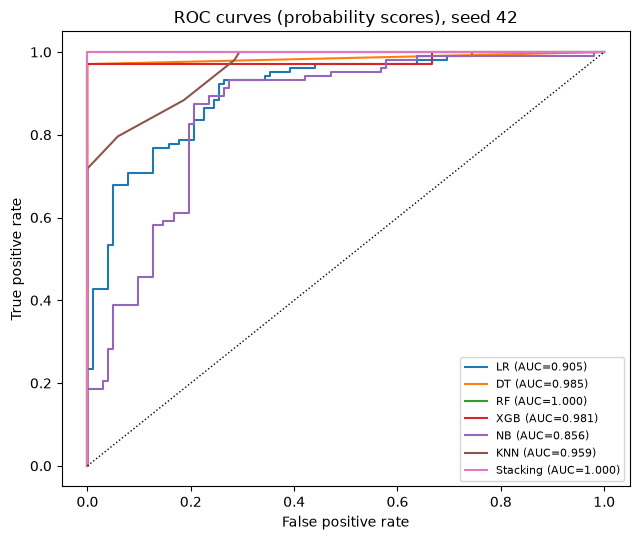

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, name in zip(axes.ravel(), MODEL_ORDER):
    ConfusionMatrixDisplay.from_predictions(y_test, preds[name], ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
axes.ravel()[-1].axis("off")
fig.suptitle("Confusion matrices on the test split (seed 42)"); fig.tight_layout()
fig.savefig(FIG_DIR / "p1_confusion_matrices.png", dpi=200); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name in MODEL_ORDER:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC={repro.loc[name, 'AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (probability scores), seed 42"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "p1_roc_curves.png", dpi=200); plt.show()

## 6. Robustness of the reproduction across 20 random splits

A single 205-sample test set gives noisy estimates, and the paper reports only one split with no seed. The full pipeline is therefore repeated over 20 random 80/20 splits (split seed = model seed = 0..19), still following the paper's protocol (1025 rows, no deduplication). Mean ± standard deviation are reported, and the paper's value is compared with the observed range.

In [9]:
records = []
for s in range(N_SEEDS):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    pipes = make_all_pipelines(s)
    for name in MODEL_ORDER:
        _, res, _, _ = fit_and_score(pipes[name], Xtr, ytr, Xte, yte)
        records.append({"seed": s, "model": name, **res})
multi = pd.DataFrame(records)
multi.to_csv(RES_DIR / "part1_multiseed_raw.csv", index=False)

summary = multi.groupby("model")[main_metrics].agg(["mean", "std"]).loc[MODEL_ORDER]
display(summary.round(4))

acc_stats = multi.groupby("model")["Accuracy"].agg(["mean", "std", "min", "max"]).loc[MODEL_ORDER]
acc_stats["paper"] = paper["Accuracy"]
# tolerance 5e-4 because the paper reports 4 decimals (e.g. 0.8439 vs 173/205 = 0.84390...)
acc_stats["paper within [min, max]"] = (acc_stats["paper"] >= acc_stats["min"] - 5e-4) & (acc_stats["paper"] <= acc_stats["max"] + 5e-4)
acc_stats.to_csv(RES_DIR / "part1_multiseed_accuracy_summary.csv")
display(acc_stats.round(4))

Accuracy         Precision          Recall              F1          \
             mean     std      mean     std    mean     std    mean     std   
model                                                                         
LR         0.8607  0.0137    0.8474  0.0308  0.8904  0.0208  0.8678  0.0140   
DT         0.9949  0.0086    0.9970  0.0092  0.9929  0.0152  0.9949  0.0084   
RF         0.9971  0.0060    0.9956  0.0108  0.9987  0.0058  0.9971  0.0059   
XGB        0.9954  0.0073    0.9956  0.0108  0.9955  0.0111  0.9955  0.0071   
NB         0.8488  0.0232    0.8302  0.0297  0.8885  0.0316  0.8579  0.0220   
KNN        0.8507  0.0202    0.8619  0.0351  0.8458  0.0283  0.8532  0.0221   
Stacking   0.9978  0.0054    0.9970  0.0092  0.9987  0.0058  0.9978  0.0053   

             AUC          
            mean     std  
model                     
LR        0.9307  0.0124  
DT        0.9951  0.0081  
RF        0.9997  0.0010  
XGB       0.9996  0.0012  
NB        0.9025  0.0180  
KNN       0.9569  0.0091  
Stacking  0.9991  0.0026

,mean,std,min,max,paper,"paper within [min, max]"
model,,,,,,
LR,0.8607,0.0137,0.8439,0.8878,0.8439,True
DT,0.9949,0.0086,0.9707,1.0000,0.9268,False
RF,0.9971,0.0060,0.9854,1.0000,0.9268,False
XGB,0.9954,0.0073,0.9805,1.0000,0.9073,False
NB,0.8488,0.0232,0.8049,0.8878,0.8439,True
KNN,0.8507,0.0202,0.8244,0.8976,0.8585,True
Stacking,0.9978,0.0054,0.9854,1.0000,0.9853,True


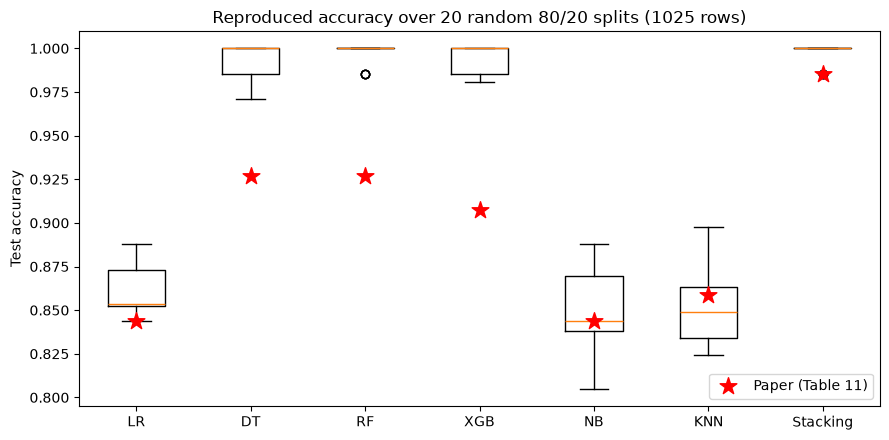

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [multi.loc[multi.model == m, "Accuracy"].values for m in MODEL_ORDER]
ax.boxplot(data, tick_labels=MODEL_ORDER)
ax.scatter(np.arange(1, len(MODEL_ORDER) + 1), paper["Accuracy"], marker="*", s=160,
           color="red", zorder=3, label="Paper (Table 11)")
ax.set_ylabel("Test accuracy"); ax.set_title(f"Reproduced accuracy over {N_SEEDS} random 80/20 splits (1025 rows)")
ax.legend(loc="lower right"); fig.tight_layout()
fig.savefig(FIG_DIR / "p1_multiseed_boxplot.png", dpi=200); plt.show()


### 6.1 Precision, recall and F1 beside the paper's values

Table 11 of the paper reports accuracy, precision, recall, F1 and AUC. The table below sets all five metrics of the reproduction (seed 42 and the mean ± std over the 20 random splits of Section 6) beside the paper's values. Precision, recall and F1 refer to `target = 1`, the same class as in the paper, so the values are directly comparable.


In [11]:

FIVE = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
mean20 = multi.groupby("model")[FIVE].mean().loc[MODEL_ORDER]
std20 = multi.groupby("model")[FIVE].std().loc[MODEL_ORDER]
full_cmp = pd.concat({"Paper": paper[FIVE], "Seed 42": repro[FIVE],
                      "20-split mean": mean20, "20-split std": std20}, axis=1)
full_cmp = full_cmp.swaplevel(axis=1)[[(m, c) for m in FIVE for c in ["Paper", "Seed 42", "20-split mean", "20-split std"]]]
full_cmp.to_csv(RES_DIR / "part1_full_metric_comparison.csv")
display(full_cmp.round(3))


Accuracy                                    Precision          \
            Paper Seed 42 20-split mean 20-split std     Paper Seed 42   
LR          0.844   0.829         0.861        0.014     0.820   0.783   
DT          0.927   0.985         0.995        0.009     0.970   1.000   
RF          0.927   0.985         0.997        0.006     0.913   1.000   
XGB         0.907   0.985         0.995        0.007     0.917   1.000   
NB          0.844   0.824         0.849        0.023     0.825   0.791   
KNN         0.858   0.849         0.851        0.020     0.865   0.827   
Stacking    0.985   0.985         0.998        0.005     1.000   1.000   

                                    Recall                                     \
         20-split mean 20-split std  Paper Seed 42 20-split mean 20-split std   
LR               0.847        0.031  0.909   0.913         0.890        0.021   
DT               0.997        0.009  0.891   0.971         0.993        0.015   
RF               0.996        0.011  0.954   0.971         0.999        0.006   
XGB              0.996        0.011  0.909   0.971         0.995        0.011   
NB               0.830        0.030  0.900   0.883         0.888        0.032   
KNN              0.862        0.035  0.873   0.883         0.846        0.028   
Stacking         0.997        0.009  0.973   0.971         0.999        0.006   

             F1                                       AUC          \
          Paper Seed 42 20-split mean 20-split std  Paper Seed 42   
LR        0.862   0.843         0.868        0.014  0.920   0.905   
DT        0.929   0.985         0.995        0.008  0.970   0.985   
RF        0.933   0.985         0.997        0.006  0.973   1.000   
XGB       0.913   0.985         0.995        0.007  0.983   0.981   
NB        0.861   0.835         0.858        0.022  0.918   0.856   
KNN       0.869   0.854         0.853        0.022  0.930   0.959   
Stacking  0.986   0.985         0.998        0.005  0.988   1.000   

                                     
         20-split mean 20-split std  
LR               0.931        0.012  
DT               0.995        0.008  
RF               1.000        0.001  
XGB              1.000        0.001  
NB               0.903        0.018  
KNN              0.957        0.009  
Stacking         0.999        0.003


### 6.2 Are the tree-model differences linked to hyperparameter choices?

The reproduced DT, RF and XGB are clearly more accurate than the paper's values (Section 6), and the paper does not report any hyperparameters. A natural hypothesis is that the authors limited the complexity of the trees. To test this, the maximum depth of each tree-based model is varied under the paper's protocol (1025 rows, random 80/20 split, the same 20 seeds as Section 6), with all other settings unchanged. For each model, the depth whose mean accuracy is closest to the paper is reported, together with its precision and recall, so that the whole metric profile can be compared, not only accuracy.

If depth-limited trees explain the paper's base-model results, the same depth-limited trees should also explain the paper's stacking result (98.53%). This is checked in the second cell.


Accuracy  Precision  Recall     F1    AUC
model max_depth                                           
DT    2             0.758      0.792   0.735  0.755  0.844
      3             0.834      0.813   0.883  0.845  0.896
      4             0.832      0.817   0.873  0.841  0.925
      5             0.884      0.855   0.933  0.892  0.959
      6             0.911      0.903   0.929  0.914  0.976
      7             0.950      0.941   0.963  0.951  0.989
      8             0.966      0.964   0.970  0.967  0.992
      None          0.995      0.997   0.993  0.995  0.995
RF    2             0.851      0.840   0.876  0.857  0.926
      3             0.867      0.851   0.900  0.874  0.940
      4             0.886      0.867   0.920  0.892  0.956
      5             0.918      0.902   0.943  0.921  0.974
      6             0.957      0.953   0.963  0.958  0.989
      8             0.990      0.985   0.997  0.991  0.999
      None          0.997      0.996   0.999  0.997  1.000
XGB   1             0.881      0.869   0.907  0.887  0.951
      2             0.960      0.967   0.956  0.961  0.989
      3             0.992      0.990   0.994  0.992  1.000
      4             0.996      0.994   0.997  0.996  1.000
      6             0.995      0.996   0.995  0.995  1.000

Depth whose mean accuracy (20 splits) is closest to the paper:


,closest max_depth,Accuracy (sweep),Precision (sweep),Recall (sweep),Accuracy (paper),Precision (paper),Recall (paper),"Accuracy (default, unlimited depth)"
model,,,,,,,,
DT,6,0.911,0.903,0.929,0.927,0.970,0.891,0.995
RF,5,0.918,0.902,0.943,0.927,0.913,0.954,0.997
XGB,1,0.881,0.869,0.907,0.907,0.917,0.909,0.995


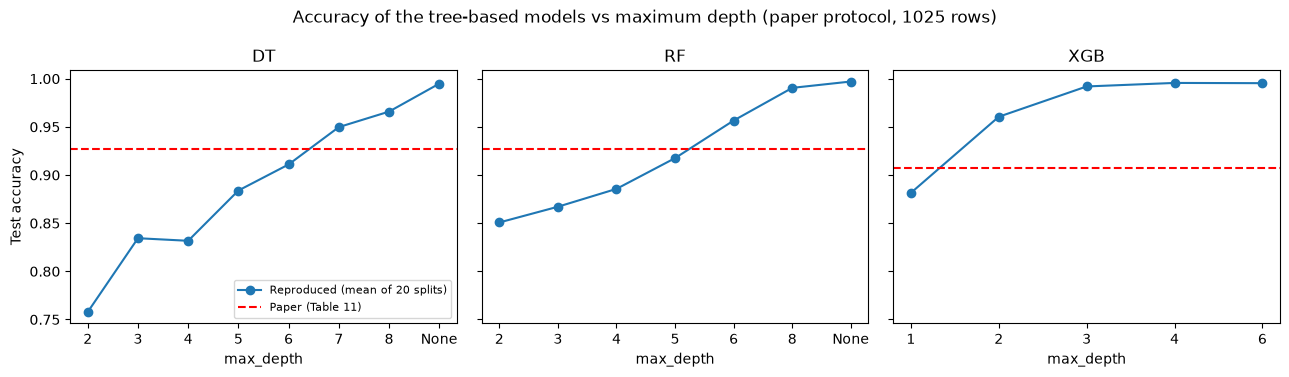

In [12]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from heart_utils import make_preprocessor, make_base_classifiers, evaluate

DEPTH_GRID = {"DT": [2, 3, 4, 5, 6, 7, 8, None], "RF": [2, 3, 4, 5, 6, 8, None], "XGB": [1, 2, 3, 4, 6]}

def tree_model(name, depth, seed):
    if name == "DT":
        return DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=seed)
    if name == "RF":
        return RandomForestClassifier(max_depth=depth, random_state=seed, n_jobs=1)
    return XGBClassifier(max_depth=depth, random_state=seed, eval_metric="logloss", n_jobs=1)

sweep_rows = []
for s in range(N_SEEDS):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    prep = make_preprocessor(s).fit(Xtr)
    A, B = prep.transform(Xtr), prep.transform(Xte)
    for name, depths in DEPTH_GRID.items():
        for d in depths:
            m = tree_model(name, d, s).fit(A, ytr)
            sweep_rows.append({"model": name, "max_depth": "None" if d is None else d, "seed": s,
                               **evaluate(yte, m.predict(B), m.predict_proba(B)[:, 1])})
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(RES_DIR / "part1_tree_depth_sweep_raw.csv", index=False)
sweep_mean = sweep.groupby(["model", "max_depth"], sort=False)[FIVE].mean()
sweep_mean.to_csv(RES_DIR / "part1_tree_depth_sweep_summary.csv")

closest = {}
rows = []
for name in DEPTH_GRID:
    tab = sweep_mean.loc[name]
    best_depth = (tab["Accuracy"] - paper.loc[name, "Accuracy"]).abs().idxmin()
    closest[name] = None if best_depth == "None" else int(best_depth)
    rows.append({"model": name, "closest max_depth": best_depth,
                 **{f"{m} (sweep)": tab.loc[best_depth, m] for m in ["Accuracy", "Precision", "Recall"]},
                 **{f"{m} (paper)": paper.loc[name, m] for m in ["Accuracy", "Precision", "Recall"]},
                 "Accuracy (default, unlimited depth)": mean20.loc[name, "Accuracy"]})
closest_tab = pd.DataFrame(rows).set_index("model")
closest_tab.to_csv(RES_DIR / "part1_tree_depth_closest.csv")
display(sweep_mean.round(3))
print("Depth whose mean accuracy (20 splits) is closest to the paper:")
display(closest_tab.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, name in zip(axes, DEPTH_GRID):
    tab = sweep_mean.loc[name]
    xs = [str(d) for d in tab.index]
    ax.plot(xs, tab["Accuracy"], marker="o", label="Reproduced (mean of 20 splits)")
    ax.axhline(paper.loc[name, "Accuracy"], color="red", ls="--", label="Paper (Table 11)")
    ax.set_title(name); ax.set_xlabel("max_depth")
axes[0].set_ylabel("Test accuracy"); axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Accuracy of the tree-based models vs maximum depth (paper protocol, 1025 rows)")
fig.tight_layout(); fig.savefig(FIG_DIR / "p1_tree_depth_sweep.png", dpi=200); plt.show()


In [13]:

# Stacking built with the depth-limited trees that best match the paper's base models
stack_limited = []
for s in range(N_SEEDS):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=s)
    base = make_base_classifiers(s)
    for name, d in closest.items():
        base[name].set_params(max_depth=d)
    stack = StackingClassifier(estimators=list(base.items()),
                               final_estimator=LogisticRegression(max_iter=1000, random_state=s),
                               cv=5, stack_method="predict_proba", n_jobs=1)
    model = Pipeline([("prep", make_preprocessor(s)), ("clf", stack)]).fit(Xtr, ytr)
    stack_limited.append(evaluate(yte, model.predict(Xte), model.predict_proba(Xte)[:, 1]))
stack_limited = pd.DataFrame(stack_limited)
stack_limited.to_csv(RES_DIR / "part1_stacking_limited_trees.csv", index=False)
print(f"Depth limits used: {closest}")
print(f"Stacking accuracy with these trees over {N_SEEDS} splits: mean {stack_limited['Accuracy'].mean():.3f}, "
      f"min {stack_limited['Accuracy'].min():.3f}, max {stack_limited['Accuracy'].max():.3f}")
print(f"Paper stacking accuracy: {paper.loc['Stacking', 'Accuracy']:.4f}")
print(f"Splits reaching the paper's stacking accuracy: {(stack_limited['Accuracy'] >= paper.loc['Stacking', 'Accuracy'] - 5e-4).sum()} / {N_SEEDS}")


Depth limits used: {'DT': 6, 'RF': 5, 'XGB': 1}
Stacking accuracy with these trees over 20 splits: mean 0.943, min 0.902, max 0.976
Paper stacking accuracy: 0.9853
Splits reaching the paper's stacking accuracy: 0 / 20


**Interpretation.** Limiting the depth of the trees brings their accuracy down to the level reported in the paper, so the difference in the base models is consistent with unreported complexity limits. The match is not equally good for every model: for RF, a depth of 5 reproduces accuracy, precision and recall closely; for DT, a depth of 6 matches the accuracy but not the paper's pattern of high precision and lower recall; for XGB, the paper's accuracy lies between depths 1 and 2. More importantly, depth limits cannot explain the paper's results as a whole: when the same depth-limited trees are stacked, the stacking accuracy stays below the paper's 98.53% in every one of the 20 splits (printed above). No single depth setting reproduces both the paper's base-model results and its stacking result. Only the maximum depth is varied here, so other unreported settings (for example the minimum leaf size or the number of trees) could also play a role; the conclusion is that the paper does not report enough detail to reproduce all of its numbers together.

## 7. Consistency check of the paper's reported numbers

The paper publishes the confusion matrix of every model (Fig. 3 for the six base classifiers, Fig. 5 for stacking). All metrics can be recomputed from these matrices and compared with Table 11. Matrix layout: rows = true class (0, 1), columns = predicted class (0, 1).

In [14]:
paper_cm = {   # [[TN, FP], [FN, TP]] read from Fig. 3 and Fig. 5 of the paper
    "LR":  [[73, 22], [10, 100]],
    "DT":  [[92, 3],  [12, 98]],
    "RF":  [[85, 10], [5, 105]],
    "XGB": [[86, 9],  [10, 100]],
    "NB":  [[74, 21], [11, 99]],
    "KNN": [[80, 15], [14, 96]],
    "Stacking": [[95, 0], [3, 107]],
}
paper_t11_extra = pd.DataFrame({   # remaining Table 11 columns
    "Sensitivity": [0.8439, 0.9268, 0.9268, 0.9073, 0.8439, 0.8585, 0.9853],
    "Specificity": [0.8620, 0.9289, 0.9333, 0.9132, 0.8608, 0.8687, 0.9861],
    "MCC":         [0.8196, 0.9702, 0.9130, 0.9174, 0.8250, 0.8648, 1.0000],
}, index=MODEL_ORDER)

recomputed = pd.DataFrame({m: metrics_from_confusion(cm[0][0], cm[0][1], cm[1][0], cm[1][1])
                           for m, cm in paper_cm.items()}).T.loc[MODEL_ORDER]
print("Test-set size in every paper confusion matrix:", {m: int(np.sum(cm)) for m, cm in paper_cm.items()})

check = pd.DataFrame({
    "Acc (recomputed)": recomputed["Accuracy"], "Acc (Table 11)": paper["Accuracy"],
    "Recall (recomputed)": recomputed["Recall"], "Sensitivity (Table 11)": paper_t11_extra["Sensitivity"],
    "Spec (recomputed)": recomputed["Specificity"], "Spec (Table 11)": paper_t11_extra["Specificity"],
    "MCC (recomputed)": recomputed["MCC"], "MCC (Table 11)": paper_t11_extra["MCC"],
})
display(check.round(4))

tol = 1e-3
print("Table 11 'Sensitivity' identical to Table 11 'Accuracy' for all models:",
      bool((paper_t11_extra["Sensitivity"] - paper["Accuracy"]).abs().max() < tol))
print("Table 11 'Specificity' identical to Table 11 'F1' for all models:",
      bool((paper_t11_extra["Specificity"] - paper["F1"]).abs().max() < tol))
print("Table 11 'MCC' identical to Table 11 'Precision' for all models:",
      bool((paper_t11_extra["MCC"] - paper["Precision"]).abs().max() < tol))
print("Accuracy recomputed from confusion matrices matches Table 11:",
      bool((recomputed["Accuracy"] - paper["Accuracy"]).abs().max() < tol))

Test-set size in every paper confusion matrix: {'LR': 205, 'DT': 205, 'RF': 205, 'XGB': 205, 'NB': 205, 'KNN': 205, 'Stacking': 205}


,Acc (recomputed),Acc (Table 11),Recall (recomputed),Sensitivity (Table 11),Spec (recomputed),Spec (Table 11),MCC (recomputed),MCC (Table 11)
LR,0.8439,0.8439,0.9091,0.8439,0.7684,0.8620,0.6883,0.8196
DT,0.9268,0.9268,0.8909,0.9268,0.9684,0.9289,0.8571,0.9702
RF,0.9268,0.9268,0.9545,0.9268,0.8947,0.9333,0.8534,0.9130
XGB,0.9073,0.9073,0.9091,0.9073,0.9053,0.9132,0.8138,0.9174
NB,0.8439,0.8439,0.9000,0.8439,0.7789,0.8608,0.6872,0.8250
KNN,0.8585,0.8585,0.8727,0.8585,0.8421,0.8687,0.7154,0.8648
Stacking,0.9854,0.9853,0.9727,0.9853,1.0000,0.9861,0.9711,1.0000


Table 11 'Sensitivity' identical to Table 11 'Accuracy' for all models: True
Table 11 'Specificity' identical to Table 11 'F1' for all models: True
Table 11 'MCC' identical to Table 11 'Precision' for all models: True
Accuracy recomputed from confusion matrices matches Table 11: True


**Other inconsistencies in the paper** (found by reading the paper; they cannot be recomputed from the data):
- Abstract and Section 5 report stacking accuracy 98.53% and XGBoost 90.73%; the Introduction (p. 36353) reports XGBoost 93.17% and stacking 96.58%.
- XGBoost AUC is 0.965 in Fig. 4 but 0.983 in Table 11 and Fig. 6. The ROC curves in Fig. 4 have a single interior point, i.e. they were computed from hard 0/1 predictions, whereas Fig. 6 uses probability scores.
- The paper claims to merge four databases (Cleveland, Hungary, Switzerland, Long Beach V), but the number of unique records in the file (Section 1 above) is close to the size of the Cleveland database alone (303 records), not the ~920 records of the four databases combined. This is checked directly against the original UCI file in Section 7.1.

### 7.1 Cross-check with the original UCI data

The Kaggle file is compared with the processed Cleveland file of the UCI Heart Disease repository (`data/processed.cleveland.data`; Janosi et al., UCI Machine Learning Repository, doi: 10.24432/C52P4X, CC BY 4.0). In the UCI file, missing values are written as `?`, and the original coding is:
- `num` (diagnosis): 0 = no disease (< 50% diameter narrowing), 1 to 4 = disease (> 50% narrowing)
- `cp`: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
- `restecg`: 0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy
- `slope`: 1 = upsloping, 2 = flat, 3 = downsloping
- `thal`: 3 = normal, 6 = fixed defect, 7 = reversible defect

Records are matched on the 8 columns that use the same coding in both files (`age, sex, trestbps, chol, fbs, thalach, exang, oldpeak`). The tables below then show how the Kaggle codes of the remaining columns correspond to the UCI codes.

In [15]:
UCI_COLS = FEATURES + ["num"]
uci = pd.read_csv(ROOT / "data" / "processed.cleveland.data", names=UCI_COLS, na_values="?")
MATCH_KEY = ["age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak"]

kaggle_unique = df.drop_duplicates()
matched = kaggle_unique.merge(uci, on=MATCH_KEY, how="left", suffixes=("_kaggle", "_uci"), indicator=True)
print(f"UCI Cleveland records: {len(uci)}")
print(f"Kaggle unique records: {len(kaggle_unique)}")
print(f"Kaggle unique records matched to a Cleveland record: {(matched['_merge'] == 'both').sum()}")
print(f"One-to-one match (no Kaggle record matched twice): {len(matched) == len(kaggle_unique)}")

mm = matched[matched["_merge"] == "both"]
uci_label = np.where(mm["num"] > 0, "UCI: disease (num 1-4)", "UCI: no disease (num 0)")
print("\nKaggle target vs original UCI diagnosis:")
display(pd.crosstab(mm["target"].rename("Kaggle target"), pd.Series(uci_label, index=mm.index, name="")))

for col in ["cp", "restecg", "slope", "ca", "thal"]:
    uci_codes = mm[f"{col}_uci"].map(lambda v: "missing (?)" if pd.isna(v) else int(v))
    print(f"\n{col}: Kaggle code (rows) vs UCI code (columns)")
    display(pd.crosstab(mm[f"{col}_kaggle"].rename(f"Kaggle {col}"), uci_codes.rename(f"UCI {col}")))

UCI Cleveland records: 303
Kaggle unique records: 302
Kaggle unique records matched to a Cleveland record: 302
One-to-one match (no Kaggle record matched twice): True

Kaggle target vs original UCI diagnosis:


,UCI: disease (num 1-4),UCI: no disease (num 0)
Kaggle target,,
0,138,0
1,0,164



cp: Kaggle code (rows) vs UCI code (columns)


UCI cp,1,2,3,4
Kaggle cp,,,,
0,0,0,0,143
1,0,50,0,0
2,0,0,86,0
3,23,0,0,0



restecg: Kaggle code (rows) vs UCI code (columns)


...

UCI slope,1,2,3
Kaggle slope,,,
0,0,0,21
1,0,140,0
2,141,0,0



ca: Kaggle code (rows) vs UCI code (columns)


UCI ca,0,1,2,3,missing (?)
Kaggle ca,,,,,
0,175,0,0,0,0
1,0,65,0,0,0
2,0,0,38,0,0
3,0,0,0,20,0
4,0,0,0,0,4



thal: Kaggle code (rows) vs UCI code (columns)


UCI thal,3,6,7,missing (?)
Kaggle thal,,,,
0,0,0,0,2
1,0,18,0,0
2,165,0,0,0
3,0,0,117,0


**Findings from the cross-check.** All unique Kaggle records match the Cleveland database one-to-one, so the file is a copy of the Cleveland data rather than a merge of four databases. Kaggle `target = 1` corresponds to UCI `num = 0` (no disease), so the label is inverted relative to the description in the paper and on Kaggle. The Kaggle codes `ca = 4` and `thal = 0` correspond exactly to the missing entries (`?`) of the UCI file, which supports treating them as missing values (Section 2). Several category codes (`cp`, `restecg`, `slope`, `thal`) are renumbered, which does not affect the models here because these columns are one-hot encoded. Accuracy and AUC are not affected by the inverted label; precision, recall and specificity refer to `target = 1` as in the paper.


### 7.2 Sensitivity to the handling of `ca = 4` and `thal = 0`

Section 7.1 shows that `ca = 4` (4 patients) and `thal = 0` (2 patients) correspond exactly to the missing entries (`?`) of the original UCI file, which is the reason for treating them as missing values and imputing them (Section 2). To check that the results do not depend on this choice, three ways of handling these codes are compared:
- **Impute (used in this study):** mark them as missing and predict them with linear-regression imputation.
- **Keep codes:** keep them as ordinary values (`thal = 0` becomes its own one-hot category, `ca = 4` stays numeric).
- **Drop records:** remove the affected rows before splitting.

The comparison uses LR (a linear model), RF (a tree ensemble) and stacking, under the paper's protocol (the same 20 random splits of the 1025 rows as Section 6) and under a leakage-free protocol (302 unique records, repeated stratified 5-fold CV with 2 repeats).


In [16]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from heart_utils import NOMINAL, NUMERIC, BINARY, make_stacking

def make_preprocessor_keep_codes(seed=0):
    return ColumnTransformer([("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), NOMINAL),
                              ("numeric", MinMaxScaler(), NUMERIC), ("binary", "passthrough", BINARY)],
                             verbose_feature_names_out=False)

def pipes_for(prep_factory, seed, names):
    models = make_base_classifiers(seed); models["Stacking"] = make_stacking(seed)
    return {n: Pipeline([("prep", prep_factory(seed)), ("clf", models[n])]) for n in names}

invalid = (df["ca"] == 4) | (df["thal"] == 0)
df_drop = df[~invalid]
print(f"Rows with ca = 4 or thal = 0: {invalid.sum()} of {len(df)} "
      f"({df[invalid].drop_duplicates().shape[0]} unique records)")

variants = {"Impute (used)": (df, make_preprocessor), "Keep codes": (df, make_preprocessor_keep_codes),
            "Drop records": (df_drop, make_preprocessor)}

# (a) Paper protocol: 20 random 80/20 splits of all rows
SENS_MODELS = ["LR", "RF", "Stacking"]
# "Impute (used)" under the paper protocol is exactly the setting of Section 6, so those results are reused
sens_rows = [{"protocol": "Paper (20 splits)", "variant": "Impute (used)", **r}
             for r in multi[multi.model.isin(SENS_MODELS)].drop(columns="seed").to_dict("records")]
for vname, (data, prep_factory) in variants.items():
    if vname == "Impute (used)":
        continue
    Xv, yv = data[FEATURES], data[TARGET]
    for s in range(N_SEEDS):
        Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=0.2, random_state=s)
        for name, pipe in pipes_for(prep_factory, s, SENS_MODELS).items():
            _, res, _, _ = fit_and_score(pipe, Xtr, ytr, Xte, yte)
            sens_rows.append({"protocol": "Paper (20 splits)", "variant": vname, "model": name, **res})

# (b) Leakage-free: unique records, repeated stratified 5-fold CV (2 repeats = 10 folds)
for vname, (data, prep_factory) in variants.items():
    u = data.drop_duplicates().reset_index(drop=True)
    Xu, yu = u[FEATURES], u[TARGET]
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=2024)
    for f, (tr, te) in enumerate(cv.split(Xu, yu)):
        for name, pipe in pipes_for(prep_factory, f, SENS_MODELS).items():
            _, res, _, _ = fit_and_score(pipe, Xu.iloc[tr], yu.iloc[tr], Xu.iloc[te], yu.iloc[te])
            sens_rows.append({"protocol": "Leakage-free (unique records, 10 CV folds)", "variant": vname, "model": name, **res})

sens = pd.DataFrame(sens_rows)
sens.to_csv(RES_DIR / "part1_missing_code_sensitivity_raw.csv", index=False)
sens_sum = sens.pivot_table(index=["protocol", "model"], columns="variant", values="Accuracy", aggfunc="mean")
sens_sum = sens_sum[list(variants)]
sens_sum["max difference"] = sens_sum.max(axis=1) - sens_sum.min(axis=1)
order = {m: i for i, m in enumerate(MODEL_ORDER)}
sens_sum = sens_sum.sort_index(key=lambda idx: idx.map(lambda v: order.get(v, v)))
sens_sum.to_csv(RES_DIR / "part1_missing_code_sensitivity_summary.csv")
print("Mean accuracy under each way of handling ca = 4 and thal = 0:")
display(sens_sum.round(3))
print(f"Largest difference between variants: {sens_sum['max difference'].max():.3f}")


Rows with ca = 4 or thal = 0: 25 of 1025 (6 unique records)
Mean accuracy under each way of handling ca = 4 and thal = 0:


variant                                              Impute (used)  \
protocol                                   model                     
Leakage-free (unique records, 10 CV folds) LR                0.846   
                                           RF                0.818   
                                           Stacking          0.829   
Paper (20 splits)                          LR                0.861   
                                           RF                0.997   
                                           Stacking          0.998   

variant                                              Keep codes  Drop records  \
protocol                                   model                                
Leakage-free (unique records, 10 CV folds) LR             0.834         0.848   
                                           RF             0.826         0.813   
                                           Stacking       0.823         0.836   
Paper (20 splits)                          LR             0.852         0.865   
                                           RF             0.998         0.998   
                                           Stacking       0.996         0.996   

variant                                              max difference  
protocol                                   model                     
Leakage-free (unique records, 10 CV folds) LR                 0.014  
                                           RF                 0.013  
                                           Stacking           0.013  
Paper (20 splits)                          LR                 0.013  
                                           RF                 0.001  
                                           Stacking           0.002

Largest difference between variants: 0.014


**Interpretation.** Only 6 unique records are affected. The mean accuracy changes by at most about 0.01 between the three ways of handling these codes (the "max difference" column), which is about the size of the split-to-split standard deviation in Section 6 (for example 0.014 for LR), and the ranking of the models does not change. The conclusions of the reproduction and of the leakage-free evaluation therefore do not depend on this preprocessing choice; imputation is kept because it follows the paper's description and the UCI evidence that these codes are missing values.

## 8. Diagnostic: train/test overlap caused by duplicate rows

If a record appears several times in the file, a random split can place copies of the same patient in both the training and the test set. The model is then evaluated partly on records it has already seen. Below: (a) the share of test rows that have an exact copy in the training set, and (b) accuracy separately on test rows that were *seen* (copy in train) and *unseen* (no copy in train).

In [17]:
train_df = X_train.assign(target=y_train); test_df = X_test.assign(target=y_test)
print(f"Seed {SEED}: {overlap_rate(train_df, test_df):.1%} of test rows have an exact copy in the training set")

over = []
for s in range(N_SEEDS):
    tr_idx, te_idx = train_test_split(df.index, test_size=0.2, random_state=s)
    over.append(overlap_rate(df.loc[tr_idx], df.loc[te_idx]))
print(f"Over {N_SEEDS} random splits: mean {np.mean(over):.1%}, min {np.min(over):.1%}, max {np.max(over):.1%}")

seen = row_keys(test_df).isin(set(row_keys(train_df))).values
print(f"Seed {SEED}: {seen.sum()} seen / {(~seen).sum()} unseen test rows")
seen_tab = pd.DataFrame({
    "Accuracy on seen rows": {m: (preds[m][seen] == y_test.values[seen]).mean() for m in MODEL_ORDER},
    "Accuracy on unseen rows": {m: (preds[m][~seen] == y_test.values[~seen]).mean() if (~seen).any() else np.nan
                                for m in MODEL_ORDER},
    "Errors on seen rows": {m: int((preds[m][seen] != y_test.values[seen]).sum()) for m in MODEL_ORDER},
    "Errors on unseen rows": {m: int((preds[m][~seen] != y_test.values[~seen]).sum()) for m in MODEL_ORDER},
}).loc[MODEL_ORDER]
seen_tab.to_csv(RES_DIR / "part1_seen_vs_unseen.csv")
display(seen_tab.round(4))

Seed 42: 97.1% of test rows have an exact copy in the training set
Over 20 random splits: mean 96.6%, min 91.2%, max 100.0%
Seed 42: 199 seen / 6 unseen test rows


,Accuracy on seen rows,Accuracy on unseen rows,Errors on seen rows,Errors on unseen rows
LR,0.8241,1.0,35,0
DT,1.0000,0.5,0,3
RF,1.0000,0.5,0,3
XGB,1.0000,0.5,0,3
NB,0.8191,1.0,36,0
KNN,0.8442,1.0,31,0
Stacking,1.0000,0.5,0,3


**Interpretation and caveat.** The number of *unseen* test rows is very small (printed above), so accuracy on unseen rows is not a reliable estimate of true performance. What the table does show is where the errors come from: the memorising models are perfect on seen rows, so their headline accuracy is determined almost entirely by records already present in the training set. A valid estimate on new patients requires a protocol without overlap, which is the subject of Part 2.

## 9. Summary of Part 1

In [18]:
best_paper = paper["Accuracy"].idxmax()
print("Single split (seed 42): reproduced vs paper accuracy")
for m in MODEL_ORDER:
    print(f"  {m:9s} reproduced {repro.loc[m, 'Accuracy']:.4f} | paper {paper.loc[m, 'Accuracy']:.4f} | "
          f"20-split mean {acc_stats.loc[m, 'mean']:.4f} ± {acc_stats.loc[m, 'std']:.4f}")
print(f"\nStacking reproduced: {repro.loc['Stacking','Accuracy']:.4f} (paper {paper.loc['Stacking','Accuracy']:.4f})")
print(f"Mean share of test rows with a copy in train: {np.mean(over):.1%}")
print(f"Unique records: {audit['unique rows']} of {audit['rows']}")

Single split (seed 42): reproduced vs paper accuracy
  LR        reproduced 0.8293 | paper 0.8439 | 20-split mean 0.8607 ± 0.0137
  DT        reproduced 0.9854 | paper 0.9268 | 20-split mean 0.9949 ± 0.0086
  RF        reproduced 0.9854 | paper 0.9268 | 20-split mean 0.9971 ± 0.0060
  XGB       reproduced 0.9854 | paper 0.9073 | 20-split mean 0.9954 ± 0.0073
  NB        reproduced 0.8244 | paper 0.8439 | 20-split mean 0.8488 ± 0.0232
  KNN       reproduced 0.8488 | paper 0.8585 | 20-split mean 0.8507 ± 0.0202
  Stacking  reproduced 0.9854 | paper 0.9853 | 20-split mean 0.9978 ± 0.0054

Stacking reproduced: 0.9854 (paper 0.9853)
Mean share of test rows with a copy in train: 96.6%
Unique records: 302 of 1025
